# Lesson 6: Exploring Deforestation Patterns: Vector-Raster Data Integration

This notebook demonstrates how to combine vector and raster datasets to analyze the timing and spatial distribution of deforestation events.

## Learning Objectives:
- Overlaying vector boundaries with raster-based forest loss data
- Temporal analysis of deforestation patterns using time-series raster data
- Spatial statistics to identify hotspots of forest loss
- Visualizing the progression of deforestation across different regions


In [3]:
# Install and load necessary packages
library(sf)
library(terra)
library(tidyterra)
library(ggnewscale)   
library(dplyr)
library(ggplot2)

# set maximum memory usage limit for as long as your current kernel remains active
# this line has been added to your code-along notebook on top of Luke's version to adjust for computing specification differences 
terraOptions(memmax = 3.5)

Linking to GEOS 3.12.1, GDAL 3.8.4, PROJ 9.4.0; sf_use_s2() is TRUE



terra 1.8.70



ERROR: Error: package or namespace load failed for ‘tidyterra’ in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 namespace ‘dplyr’ 1.1.4 is being loaded, but >= 1.2.0 is required


## Let's load our vector data

These are all the same vector data as in Lesson 5.

In [4]:
# Load the Philippines shapefile from local data
regions <- st_read("../../geospatial-data/simplified/regions_simplified.shp", quiet = TRUE)
provinces <- st_read("../../geospatial-data/simplified/provinces_simplified.shp", quiet = TRUE)

# Get roads provincial capitals of the Philippines
cities <- st_read("../../geospatial-data/phl_admp_adm2_capitals/phl_admp_adm2_capitals.shp", quiet = TRUE)

# Get philippines roads
roads <- st_read("../../geospatial-data/hotosm_phl_roads_lines_shp/hotosm_phl_roads_lines_shp.shp", quiet = TRUE) %>% 
  filter(highway %in% c("primary", "secondary"))



## And our raster data
Our familiar global forest change (hansen) data.

In [5]:
# Load the Hansen Global Forest Change dataset as a raster
hansen <- terra::rast("../../geospatial-data/raster/hansen.tif")

## And let's make sure it is all in same CRS

In [0]:
# Check CRS compatibility
cat("Provinces CRS:\n", st_crs(provinces)$input, "\n\n")
cat("Regions CRS:\n", st_crs(regions)$input, "\n\n")
cat("Roads CRS:\n", st_crs(roads)$input, "\n\n")
cat("Cities CRS:\n", st_crs(cities)$input, "\n\n")
cat("Raster CRS:\n", crs(hansen), "\n\n")

Let's get everything into UTM zone 51N

In [0]:
# Get the CRS from the Hansen raster
hansen_crs <- crs(hansen)

# Transform all vector data to match the Hansen raster CRS
provinces <- st_transform(provinces, hansen_crs)
regions <- st_transform(regions, hansen_crs)
roads <- st_transform(roads, hansen_crs)
cities <- st_transform(cities, hansen_crs)


## Let's map raster and vector data!

First I will do the same masking procedure as in lesson 4 so we only get real tree cover data. Then I will add geom_spatraster and geom_sf layers to the plot.

In [0]:
treecover2000 <- hansen$treecover2000  # Tree cover percentage in the year 2000
lossyear <- hansen$lossyear
datamask <- hansen$datamask

lossyear_masked <- lossyear
lossyear_masked[datamask != 1 | lossyear == 0 | treecover2000 == 0] <- NA
treecover2000_masked <- treecover2000
treecover2000_masked[datamask != 1] <- NA

# Plot tree cover with region boundaries using ggplot
ggplot() +
  # Add the raster layer directly
  geom_spatraster(data = treecover2000_masked) +
  # Add region boundaries with black outlines
  geom_sf(data = regions, fill = NA, color = "black", size = 0.5) +
  # Add a color scale for tree cover percentage - black to dark green
  scale_fill_gradient(name = "Tree Cover %\n(2000)", 
                      low = "white", 
                      high = "darkgreen", 
                      na.value = "transparent") +
  # Add labels and title
  labs(
    title = "Tree Cover in 2000 with Region Boundaries",
    x = "Longitude",
    y = "Latitude"
  ) +
  # Use a clean theme
  theme_minimal() +
  # Ensure the map uses the correct aspect ratio
  coord_sf()





## Now let's look at initial forest cover for each region
We will do this by taking "zonal statistics" of the treecover raster, which means doing a by-region summary of the raster data.

Below we've taken the sum of the tree cover raster for each region. You can learn more about the `terra::extract()` function by typing `?terra::extract` in the console.


In [0]:
# Extract tree cover values for each region

# Calculate zonal statistics - sum of tree cover for each region
region_treecover <- terra::extract(
  treecover2000_masked, #raster layer
  regions, #polygon layer
  fun = sum, #function to apply
  na.rm = TRUE, #ignore NA values
  ID = FALSE, #don't an ID variable
  bind = TRUE)  %>% #bind the results into the vector data as a new variable
  select(ADM1ALT1EN, treecover2000) %>% #select the ADM1ALT1EN and treecover2000 variables
  arrange(desc(treecover2000)) #arrange the results in descending order of treecover2000

print(region_treecover)


# Create a summary plot
ggplot(region_treecover, aes(x = reorder(ADM1ALT1EN, -treecover2000), y = treecover2000)) +
  geom_col(fill = "darkgreen") +
  labs(
    title = "Total Tree Cover by Region (2000)",
    x = "Region",
    y = "Total Tree Cover"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


## What does the above mean? It is the sum of canopy cover for all cells in each region.
Unfortunately not all cells are the same size (they are defined in terms of decimal degrees, which are not the same everywhere). 

Doing zonal statistics like this is fine if you have a raster that is natively interpretable, but this doesn't really tell us much. What if we want to know what the area of each region was with above 25% canopy cover?

To do this we'll create a raster layer that is 1 if it has above 25% canopy cover in 2000 and 0 otherwise. Then we'll multiply this by the cell area and then take the sum of the raster for each region.

In [0]:
# Extract areas with tree cover > 25% for each region

# First create a binary mask where tree cover > 25%
treecover_gt25 <- treecover2000_masked > 25

# Calculate the area of each cell in square kilometers
cell_area <- terra::cellSize(treecover_gt25, unit="km")

# Multiply the binary mask by the cell area to get area with tree cover > 25%
treecover_gt25_area <- treecover_gt25 * cell_area

# Calculate zonal statistics - sum of areas with tree cover > 25% for each region
region_treecover_gt25 <- terra::extract(
  treecover_gt25_area, 
  regions, 
  fun = sum, 
  na.rm = TRUE,
  ID = FALSE,
  bind = TRUE
) %>%
  select(ADM1ALT1EN, treecover2000) %>%
  rename(treecover_gt25_area_km2 = treecover2000) %>%
  arrange(desc(treecover_gt25_area_km2))

print(region_treecover_gt25)

# Create a summary plot
ggplot(region_treecover_gt25, aes(x = reorder(ADM1ALT1EN, -treecover_gt25_area_km2), y = treecover_gt25_area_km2)) +
  geom_col(fill = "forestgreen") +
  labs(
    title = "Area with Tree Cover > 25% by Region (2000)",
    x = "Region",
    y = "Area with Tree Cover > 25% (sqkm)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



### Exercise: can you create a map with the color of each region corresponding to the area with above 25% canopy cover?

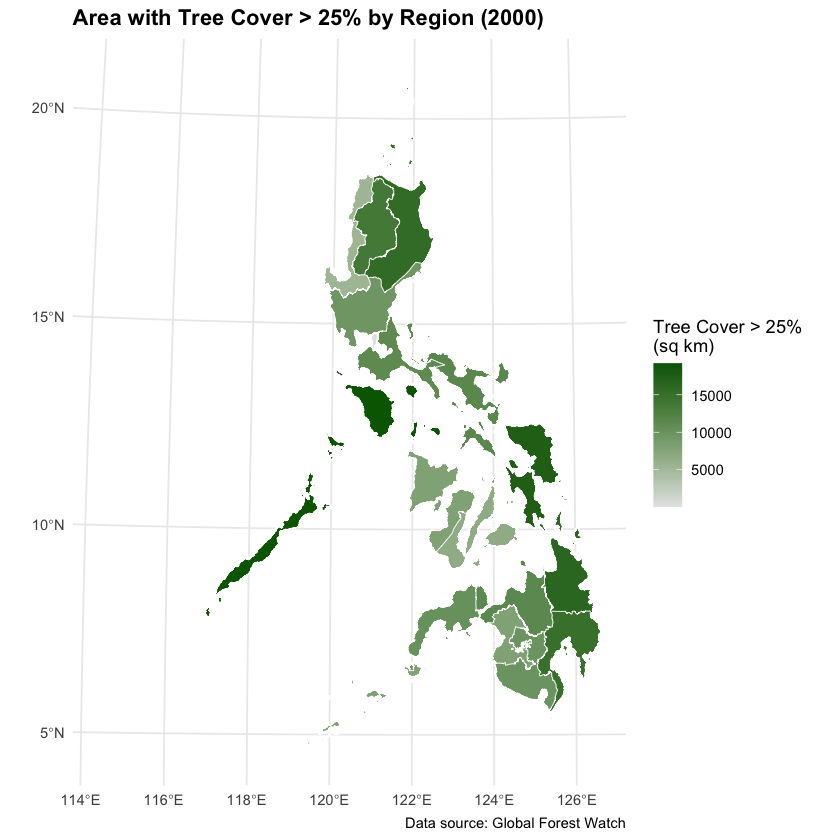

In [17]:
# Create a map with regions colored by tree cover > 25% area

# Create a map
# YOUR CODE HERE


## We could do the same thing for forest loss. 

Remember that it took a while to run zonal statistics for one layer, so do calculate the area of cells with forest loss in each year will require us to do zonal statistics 23 times. Instead, I will put the code below (with a line to save the results) so you can load the results instead.

In [0]:
# Calculate forest loss area by year for each region

# First, create a list to store results for each year
yearly_loss_by_region <- list()

# Define the years to analyze (assuming lossyear values are 1-23 for 2001-2023)
years <- 1:23
actual_years <- 2000 + years

# Calculate the area of each cell in square kilometers
cell_area <- terra::cellSize(lossyear_masked, unit="km")

# Loop through each year
for (year_code in years) {
  print(paste0("Starting year ", year_code))
  # Create a binary mask for the current year
  year_mask <- lossyear_masked == year_code
  
  # Multiply the binary mask by the cell area to get area lost in that year
  loss_area <- year_mask * cell_area * treecover_gt25
  
  # Calculate zonal statistics - sum of loss areas for each region
  year_loss <- terra::extract(
    loss_area, 
    regions, 
    fun = sum, 
    na.rm = TRUE,
    ID = FALSE,
    bind = TRUE
  ) %>%
    select(ADM1ALT1EN, lossyear) %>%
    rename(loss_area_km2 = lossyear) %>%
    mutate(year = actual_years[year_code])
  
  # Add to our list
  yearly_loss_by_region[[year_code]] <- as.data.frame(year_loss)
}
# Combine all years into a single dataframe
all_yearly_loss <- bind_rows(yearly_loss_by_region)


# Save the forest loss by region data to an RData file
save(all_yearly_loss, file = "data/output/region_loss.Rdata")




### Let's just grab the data that I saved from that process and plot it instead:

In [0]:
load("../../geospatial-data/output/region_loss.Rdata")
# Create a summary plot
ggplot(all_yearly_loss, aes(x = year, y = loss_area_km2, color = ADM1ALT1EN)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  labs(
    title = "Forest Loss Area by Year and Region",
    x = "Year",
    y = "Forest Loss Area (sqkm)",
    color = "Region"
  ) +
  theme_minimal() +
  scale_x_continuous(breaks = actual_years)


## What if we want to do the same thing for capital cities?

### Exercise:
Let's get all the capital cities, create 50km buffers around them and measure initial forest cover and forest loss in each year just like I did above for regions.

In [0]:
# Create 50km buffers around each city
city_buffers <- st_buffer(cities, dist = 10000)
# Remember that treecover_gt25_area is the area of each cell with treecover greater than 25:

hist(treecover_gt25_area)

# Calculate zonal statistics - sum of areas with tree cover > 25% for each city buffer
city_treecover_gt25 <- terra::extract(
  treecover_gt25_area, 
  city_buffers, 
  fun = sum, 
  na.rm = TRUE,
  ID = FALSE,
  bind = TRUE
) %>%
  select(Mun_Name, treecover2000) %>%
  rename(treecover_gt25_area_km2 = treecover2000) %>%
  arrange(desc(treecover_gt25_area_km2))

print(city_treecover_gt25)
 # YOUR CODE HERE
# Create a summary plot
ggplot(city_treecover_gt25, aes(x = reorder(Mun_Name, -treecover_gt25_area_km2), y = treecover_gt25_area_km2)) +
  geom_col(fill = "forestgreen") +
  labs(
    title = "Area with Tree Cover > 25% by City (2000)",
    x = "City",
    y = "Area with Tree Cover > 25% (sqkm)"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))
  # YOUR CODE HERE

## Exercise: Now you make the tree loss by year for each city in the Central Luzon region.

Hint: The cities dataset has a region variable (`cities$Reg_Name`), and for that region the name is "REGION III (CENTRAL LUZON)" 

I have put some comments below to help guide you on the steps you need to take.

[1] "Starting year 1"                     
[1] "Starting year 2"
[1] "Starting year 3"
[1] "Starting year 4"
[1] "Starting year 5"
[1] "Starting year 6"
[1] "Starting year 7"
[1] "Starting year 8"
[1] "Starting year 9"
[1] "Starting year 10"
[1] "Starting year 11"
[1] "Starting year 12"
[1] "Starting year 13"
[1] "Starting year 14"
[1] "Starting year 15"
[1] "Starting year 16"
[1] "Starting year 17"
[1] "Starting year 18"
[1] "Starting year 19"
[1] "Starting year 20"
[1] "Starting year 21"
[1] "Starting year 22"
[1] "Starting year 23"


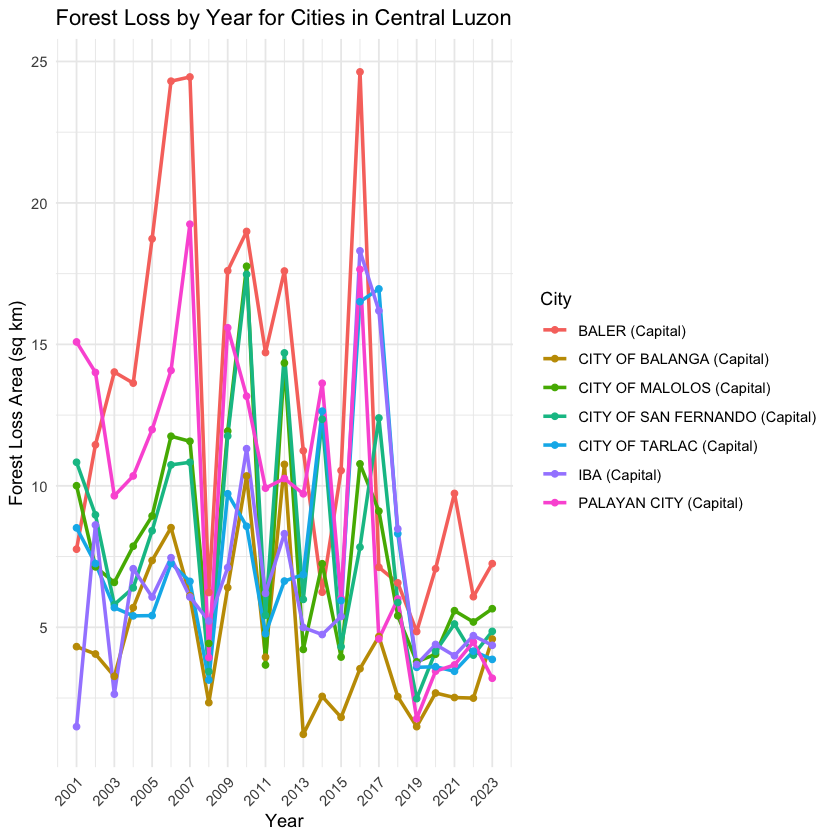

In [25]:
# Filter cities to only those in Central Luzon
# YOUR CODE HERE

# Create 50km buffers around each Central Luzon city
# YOUR CODE HERE

# First, create a list to store results for each year
# YOUR CODE HERE

# Define the years to analyze (lossyear values are 1-23 for 2001-2023)
years <- 1:23
actual_years <- 2000 + years

# Calculate the area of each cell in square kilometers (this works regardless of the CRS)
# YOUR CODE HERE

# Loop through each year
for (year_code in years) {
  print(paste0("Starting year ", year_code))
  # Create a binary mask for the current year
  # YOUR CODE HERE
  
  # Multiply the binary mask by the cell area to get area lost in that year
  # YOUR CODE HERE
  
  # Calculate zonal statistics - sum of loss areas for each city
  # YOUR CODE HERE

  
  # Add to our list
  # YOUR CODE HERE
}

# Combine all years into a single dataframe
# YOUR CODE HERE

# Create a line graph of forest loss by year for each city
# YOUR CODE HERE


## Let's focus on Baler
Let's make a map of initial forest and forest loss around Baler, and put our roads data on top of that to see if it looks like deforestation is following roads.

In [0]:
# Filter to get just Baler
baler <- cities %>%
  filter(Mun_Name == "BALER (Capital)")

# Create a 50km buffer around Baler
baler_50km <- st_buffer(baler, dist = 20000)  # 50km in meters

# Clip the tree cover and loss year rasters to the buffer
baler_treecover <- terra::crop(treecover2000_masked, baler_50km) %>%
  terra::mask(baler_50km)

baler_lossyear <- terra::crop(lossyear_masked, baler_50km) %>%
  terra::mask(baler_50km)

# Filter roads to only include those that intersect with the 50km buffer around Baler
roads_baler <- roads %>%
  st_intersection(st_as_sf(baler_50km))


# Create a map showing Baler, tree cover, forest loss, and roads
ggplot() +
  # Add tree cover as base layer
  geom_spatraster(data = baler_treecover) +
  scale_fill_gradient(
    name = "Tree Cover 2000 (%)",
    na.value = "transparent",
    low = "grey80",
    high = "darkgreen"
  ) +
  # Add forest loss year
  new_scale_fill() +
  geom_spatraster(data = baler_lossyear, alpha = 0.7) +
  scale_fill_gradient(
    name = "Loss Year",
    na.value = "transparent",
    low = "yellow",
    high = "purple"
  ) +
  # Add roads
  geom_sf(data = roads_baler, color = "blue", size = 0.5) +
  # Add Baler boundary
  geom_sf(data = st_as_sf(baler), fill = NA, color = "blue", size = 3) +
  # Add 50km buffer outline
  geom_sf(data = st_as_sf(baler_50km), fill = NA, color = "red", linetype = "dashed") +
  # Add labels and theme
  labs(
    title = "Forest Cover and Loss Around Baler with Roads",
    subtitle = "Tree cover (2000) with forest loss years and road network"
  ) +
  theme_minimal() +
  coord_sf()


### Exercise:
Let's do the same thing but for a different city. Vary the buffer size and play with the aesthetics to make it look nice!

In [0]:
# YOUR CODE HERE

# Recap of Learning Objectives

In this lesson, we've accomplished the following learning objectives:

1. **Overlaying vector boundaries with raster-based forest loss data**
   - We combined vector data (Baler boundaries, road networks) with raster data (tree cover and forest loss)
   - We used `st_intersection()` to filter roads that intersect with our area of interest

2. **Temporal analysis of deforestation patterns**
   - We visualized forest loss years using color gradients to show when deforestation occurred
   - The progression of forest loss is visible through the color scheme from yellow to purple

3. **Spatial statistics to identify hotspots**
   - We analyzed forest cover and loss within specific buffer zones (50km around Baler)
   - We masked raster data to focus on our area of interest

4. **Visualizing deforestation progression**
   - We created comprehensive maps showing multiple layers of information
   - We used appropriate color scales and transparency to show relationships between different spatial elements

These techniques allow us to understand where, when, and potentially why deforestation is occurring in specific regions.
